In [39]:
from source_code import *
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("bmh")

else:
            K = kwargs.get('K', 1) # get K
            subintervals = np.linspace(self.start, self.end, K+1,endpoint=True) # create {v0, v1, ..., vK} with K+1 points
            for i in range(K): # loop through each subinterval
                sub_start = subintervals[i] # get start of subinterval
                sub_end = subintervals[i+1] # get end of subinterval

                # interpolate on the subinterval
                self.x_values = self.point_function(n=self.num_points)
                self.y_values = self.func(np.array(self.x_values))


                if i == 0: # if first subinterval, initialize total x and y values
                    self.x_values_total = self.x_values
                    self.y_values_total = self.y_values

                # else, concatenate the new x and y values to the total x and y values
                else:
                    self.x_values_total = np.concatenate((self.x_values_total, self.x_values))
                    self.y_values_total = np.concatenate((self.y_values_total, self.y_values))


copilot gave me this, but it did not work. It does not take into consideration change of start and end points. I noticed it by looking at the self.point_function call and not seeing start and end being included


In [ ]:
def test_error_aprox(function_intervals):
    """
    Approximate and plots the L2 and max error of the Lagrange interpolation for a list of functions and intervals.

    Parameters:
    function_intervals (list of tuples): A list of tuples, where each tuple contains a function (as a string), a start point, and an end point for the interval.
    
    
    Returns:
    None
    """

    n_vals = np.arange(2, 40) # Number of points to test

    # Create subplots for each function and interval
    fig, axes = plt.subplots(
        len(function_intervals),
        2,
        figsize=(14, 5 * len(function_intervals)),
        squeeze=False
    )

    # Loop through each function and interval, and plot the errors for both equidistant and Chebyshev points
    for row, (func, start, end) in enumerate(function_intervals):
        for col, point_type in enumerate(["equidistant", "chebyshev"]):
            errors_max = []
            errors_l2 = []

            for n in n_vals: # Loop through the number of points
                # Create the LagrangeInterpolator object
                interpolator = LagrangeInterpolator(
                    start,
                    end,
                    num_points=n,
                    function=func,
                    point_type=point_type
                )

                # Calculate the errors for both norms and append them to the respective lists
                errors_max.append(interpolator.error_aprox(norm="max"))
                errors_l2.append(interpolator.error_aprox(norm="l2"))

            # Plot the errors for both norms on the same subplot
            ax = axes[row, col]
            ax.plot(n_vals, errors_max, label="Max norm", marker="o")
            ax.plot(n_vals, errors_l2, label="L2 norm", marker="o")

            ax.set_title(f"{func}: [{start}, {end}] ({point_type})")
            ax.set_xlabel("Number of points")
            ax.set_ylabel("Error")
            ax.set_yscale("log")
            ax.grid(True)
            ax.legend()

    plt.tight_layout()
    plt.show()

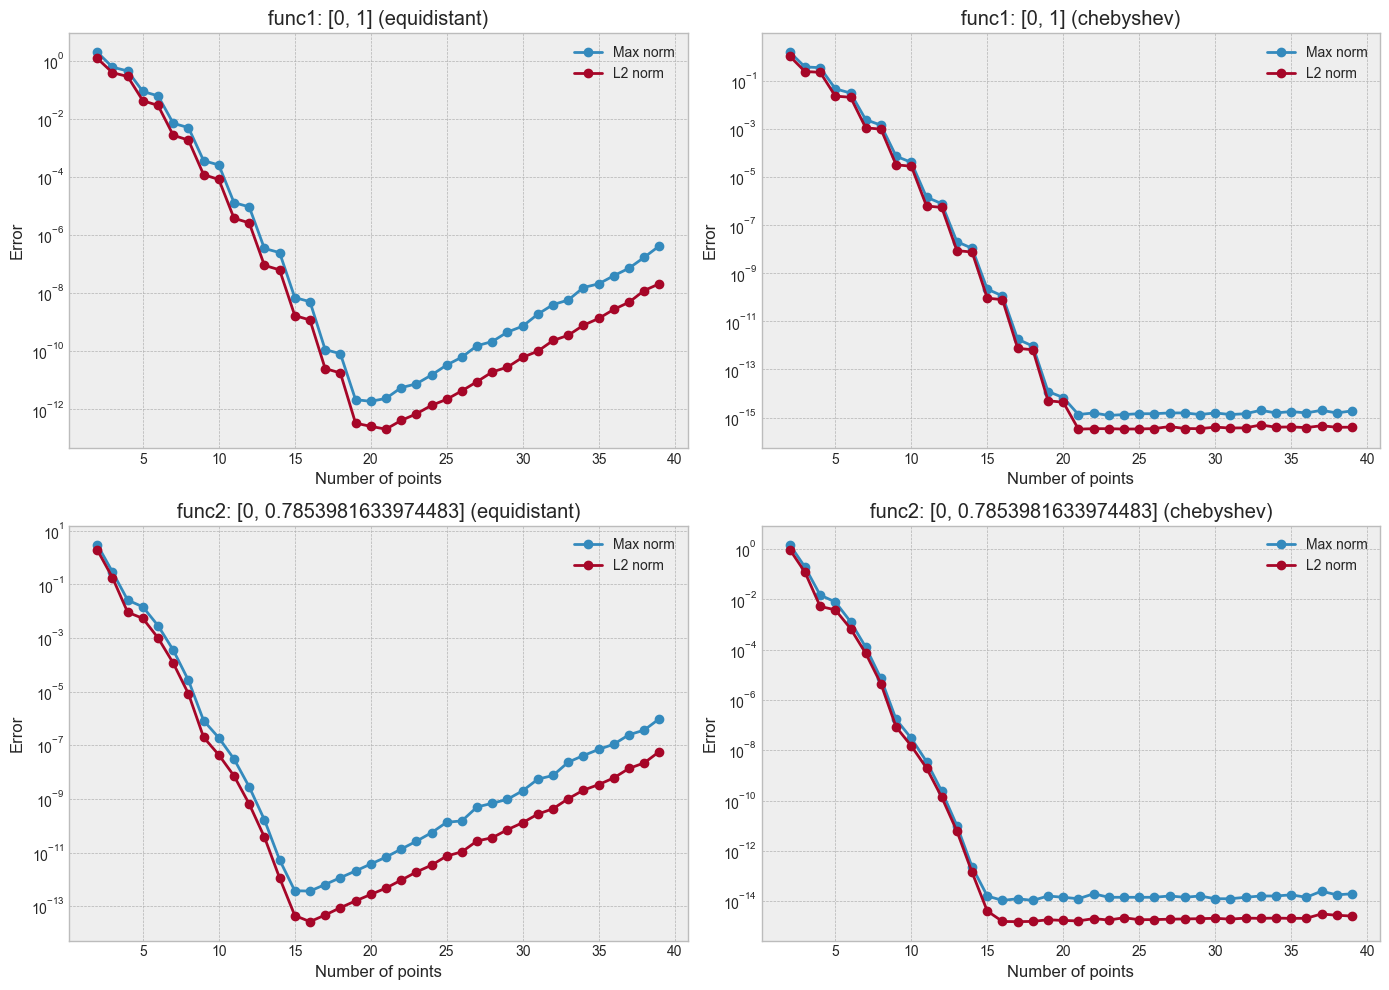

In [41]:
test_error_aprox([
    ("func1", 0, 1),
    ("func2", 0, np.pi / 4)
])